Edge Detection Techniques
A) Canny Edge Detection


Saving my_image.jpeg to my_image.jpeg


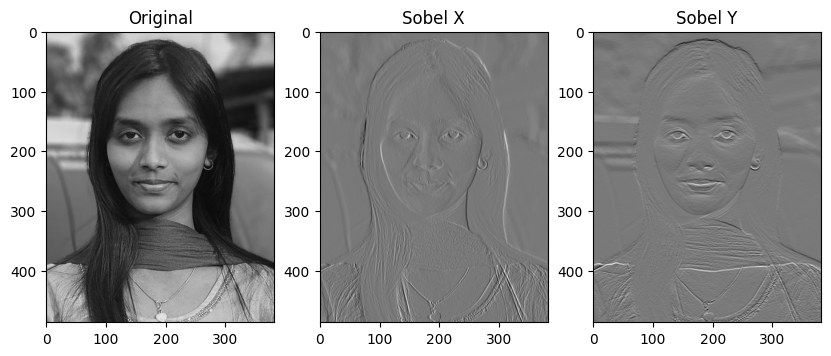

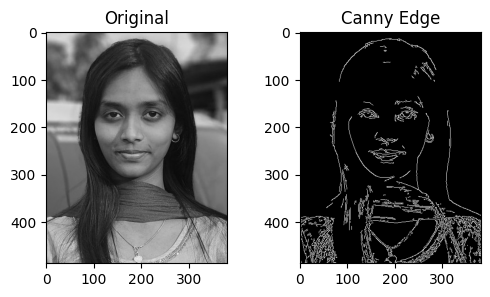

In [2]:
import cv2
import matplotlib.pyplot as plt
from google.colab import files

# Upload image
uploaded = files.upload()

# Load image
img = cv2.imread("my_image.jpeg", 0)

if img is None:
    print("❌ Image not loaded. Check filename!")
else:
    # Sobel edges
    sobelx = cv2.Sobel(img, cv2.CV_64F, 1, 0, ksize=3)
    sobely = cv2.Sobel(img, cv2.CV_64F, 0, 1, ksize=3)

    # Canny edges
    edges = cv2.Canny(img, 100, 200)

    # Plot
    plt.figure(figsize=(10,4))

    plt.subplot(1,3,1)
    plt.imshow(img, cmap='gray')
    plt.title("Original")

    plt.subplot(1,3,2)
    plt.imshow(sobelx, cmap='gray')
    plt.title("Sobel X")

    plt.subplot(1,3,3)
    plt.imshow(sobely, cmap='gray')
    plt.title("Sobel Y")

    plt.show()

    plt.figure(figsize=(6,3))
    plt.subplot(1,2,1)
    plt.imshow(img, cmap='gray')
    plt.title("Original")

    plt.subplot(1,2,2)
    plt.imshow(edges, cmap='gray')
    plt.title("Canny Edge")

    plt.show()

B) Sobel Edge Detection

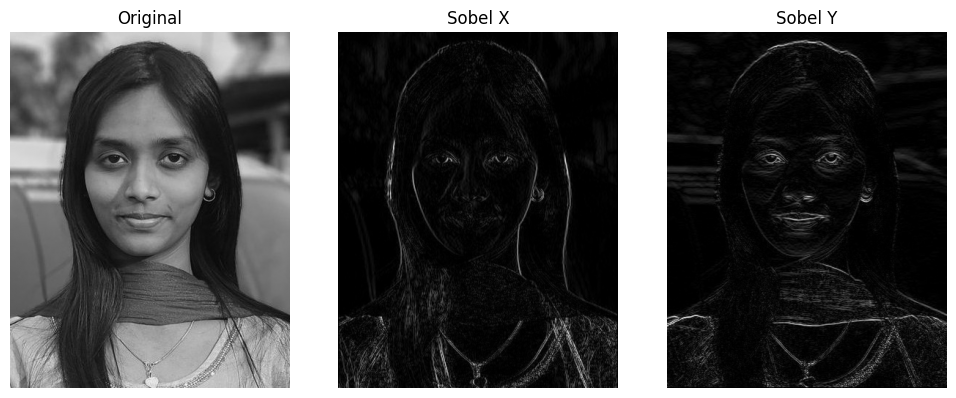

In [1]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

# Read image in grayscale
img = cv2.imread("/content/my_image.jpeg", 0)

# Check if image is loaded properly
if img is None:
    print("Error: Image not found. Check the path.")
    exit()

# Sobel edge detection
sobelx = cv2.Sobel(img, cv2.CV_64F, 1, 0, ksize=3)
sobely = cv2.Sobel(img, cv2.CV_64F, 0, 1, ksize=3)

# Convert to absolute values (important for display)
sobelx = np.absolute(sobelx)
sobely = np.absolute(sobely)

# Plot results
plt.figure(figsize=(10, 4))

plt.subplot(1, 3, 1)
plt.imshow(img, cmap='gray')
plt.title("Original")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(sobelx, cmap='gray')
plt.title("Sobel X")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(sobely, cmap='gray')
plt.title("Sobel Y")
plt.axis("off")

plt.tight_layout()
plt.show()

Corner Detection
Harris Corner Detection

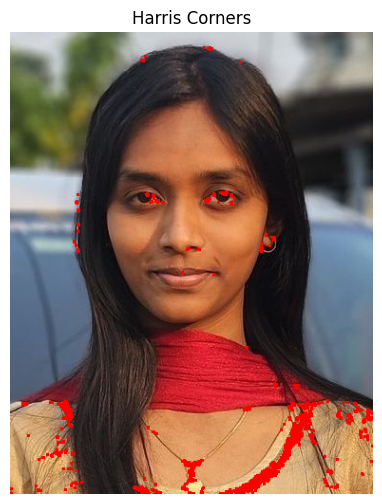

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Read image
img = cv2.imread("/content/my_image.jpeg")

# Safety check
if img is None:
    print("Error: Image not found. Check path.")
    exit()

# Convert to grayscale
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Convert to float32 (required for Harris)
gray = np.float32(gray)

# Harris Corner Detection
dst = cv2.cornerHarris(gray, 2, 3, 0.04)

# Dilate result to mark corners better
dst = cv2.dilate(dst, None)

# Mark corners on original image
img_copy = img.copy()
img_copy[dst > 0.01 * dst.max()] = [0, 0, 255]  # Red color in BGR

# Display
plt.figure(figsize=(6, 6))
plt.imshow(cv2.cvtColor(img_copy, cv2.COLOR_BGR2RGB))
plt.title("Harris Corners")
plt.axis("off")
plt.show()

Interest Point Detection
SIFT Feature Detection

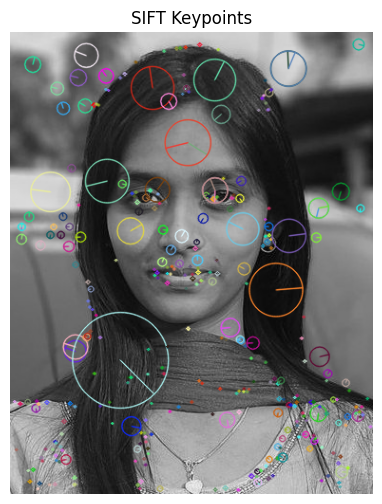

In [3]:
import cv2
import matplotlib.pyplot as plt

# Read image in grayscale
img = cv2.imread("/content/my_image.jpeg", 0)

# Safety check
if img is None:
    print("Error: Image not found. Check the path.")
    exit()

# Create SIFT detector
sift = cv2.SIFT_create()

# Detect keypoints and descriptors
keypoints, descriptors = sift.detectAndCompute(img, None)

# Draw keypoints on image
output = cv2.drawKeypoints(
    img,
    keypoints,
    None,
    flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS
)

# Display
plt.figure(figsize=(6, 6))
plt.imshow(output, cmap='gray')
plt.title("SIFT Keypoints")
plt.axis("off")
plt.show()

4. Mathematical Morphology
Suppose the binary image contains white objects.
A) Dilation

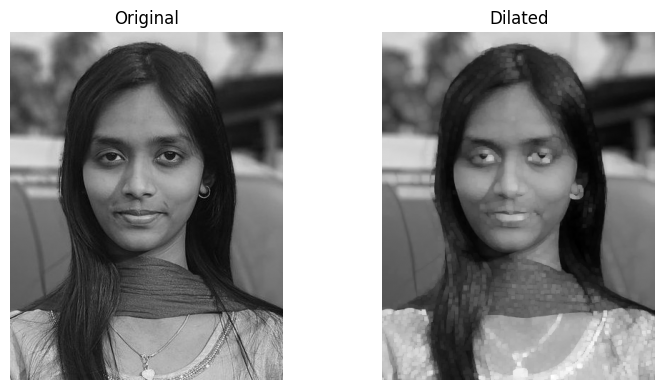

In [4]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Read binary image
img = cv2.imread("/content/my_image.jpeg", 0)

# Safety check
if img is None:
    print("Error: Image not found. Check the path.")
    exit()

# Kernel (structuring element)
kernel = np.ones((5, 5), np.uint8)

# Dilation
dilation = cv2.dilate(img, kernel, iterations=1)

# Plot results
plt.figure(figsize=(8, 4))

plt.subplot(1, 2, 1)
plt.imshow(img, cmap='gray')
plt.title("Original")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(dilation, cmap='gray')
plt.title("Dilated")
plt.axis("off")

plt.tight_layout()
plt.show()

B) Erosion

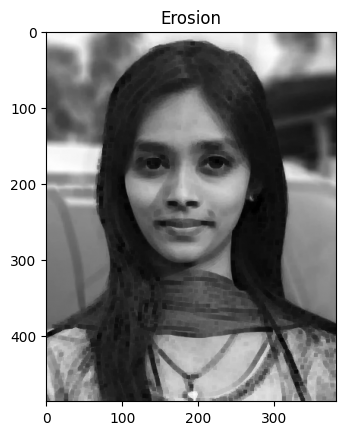

In [5]:
erosion = cv2.erode(img,kernel,iterations=1)

plt.imshow(erosion,cmap='gray')
plt.title("Erosion")
plt.show()

C) Opening

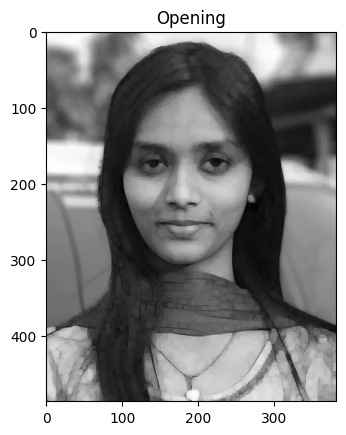

In [6]:
opening = cv2.morphologyEx(img,cv2.MORPH_OPEN,kernel)

plt.imshow(opening,cmap='gray')
plt.title("Opening")
plt.show()

5. Texture Analysis
Local Binary Pattern (LBP)

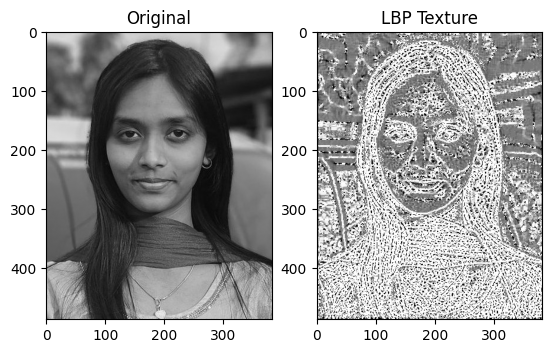

In [7]:
from skimage.feature import local_binary_pattern
import cv2
import matplotlib.pyplot as plt

image = cv2.imread("/content/my_image.jpeg",0)

radius = 3
points = 8*radius

lbp = local_binary_pattern(image,points,radius,method='uniform')

plt.subplot(121)
plt.imshow(image,cmap='gray')
plt.title("Original")

plt.subplot(122)
plt.imshow(lbp,cmap='gray')
plt.title("LBP Texture")

plt.show()

Combined Program (Edge + Corner + Morphology)

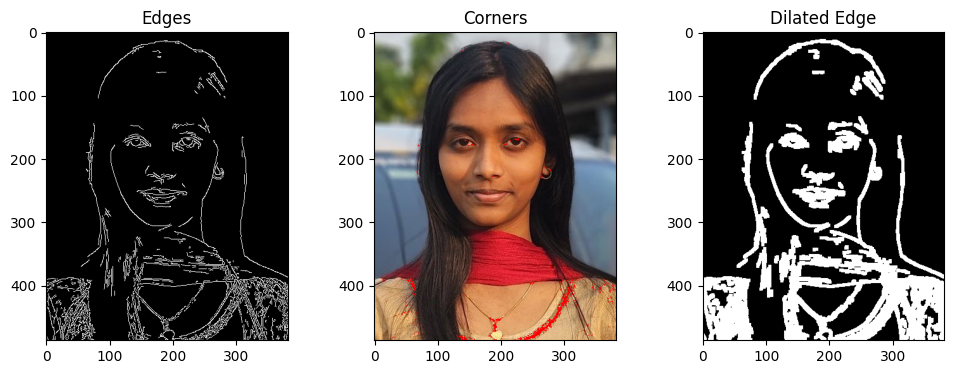

In [8]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread("/content/my_image.jpeg")
gray = cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)

# Edge Detection
edges = cv2.Canny(gray,100,200)

# Harris Corner
grayf = np.float32(gray)
corners = cv2.cornerHarris(grayf,2,3,0.04)

corner_img = img.copy()
corner_img[corners>0.01*corners.max()] = [0,0,255]

# Morphology
kernel = np.ones((5,5),np.uint8)
dilate = cv2.dilate(edges,kernel)

plt.figure(figsize=(12,4))

plt.subplot(131)
plt.imshow(edges,cmap='gray')
plt.title("Edges")

plt.subplot(132)
plt.imshow(cv2.cvtColor(corner_img,cv2.COLOR_BGR2RGB))
plt.title("Corners")

plt.subplot(133)
plt.imshow(dilate,cmap='gray')
plt.title("Dilated Edge")

plt.show()